# 📈 Training Performance & Convergence Analysis

In [1]:
%matplotlib inline

import os
import json
import numpy as np
import matplotlib.pyplot as plt

### Training History Log

In [2]:
history_path = '../training_history.json'

if os.path.exists(history_path):
    with open(history_path, 'r') as file:
        history = json.load(file)
        
    epoch_losses = history['train_loss']
    best_epoch = history['best_epoch']
    min_loss_val = epoch_losses[best_epoch - 1]
    epochs = np.arange(1, len(epoch_losses) + 1)
    
    print(f"[INFO] Successfully loaded training metrics.")
    print(f"Total Epochs Processed: {len(epoch_losses)}")
    print(f"Lowest Achieved Loss:   {min_loss_val:.4f} (at Epoch {best_epoch})")
else:
    print(f"[ERROR] '{history_path}' not found!")
    print("Please run 'python main.py --mode train' first to generate the metrics file.")
    
    # Fallback empty lists to prevent graphing errors
    epoch_losses = []
    epochs = []
    best_epoch = 0
    min_loss_val = 0

[INFO] Successfully loaded training metrics.
Total Epochs Processed: 46
Lowest Achieved Loss:   0.2343 (at Epoch 36)


### Loss Optimization Curve

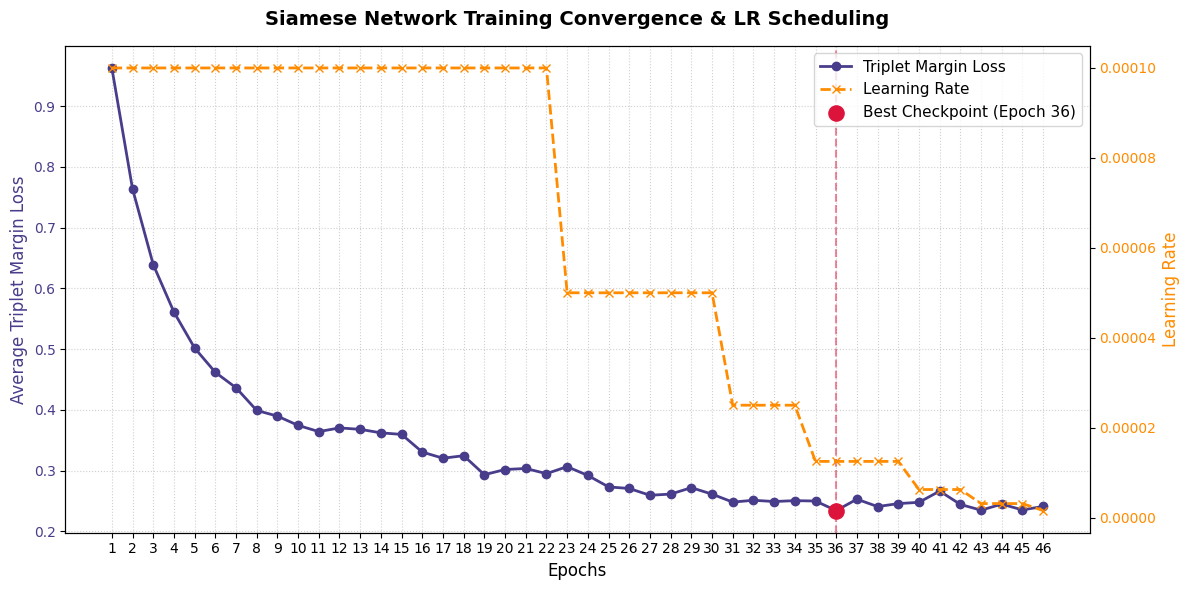

In [3]:
if len(epoch_losses) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 1. Plot Triplet Margin Loss on the left axis (ax1)
    color = 'darkslateblue'
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Average Triplet Margin Loss', color=color, fontsize=12)
    line1 = ax1.plot(epochs, epoch_losses, color=color, marker='o', lw=2, label='Triplet Margin Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(epochs)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # 2. Create a twin axis sharing the same x-axis for the Learning Rate (ax2)
    ax2 = ax1.twinx()  
    color = 'darkorange'
    ax2.set_ylabel('Learning Rate', color=color, fontsize=12)
    
    # FIXED: Fallback now uses the first recorded LR from history, removing dependency on 'config'
    lr_history = history.get('learning_rates', [history['train_loss'][0]] * len(epoch_losses))
    
    line2 = ax2.plot(epochs, lr_history, color=color, marker='x', linestyle='--', lw=2, label='Learning Rate')
    ax2.tick_params(axis='y', labelcolor=color)

    # 3. Highlight the Early Stopping checkpoint
    ax1.scatter(best_epoch, min_loss_val, color='crimson', s=120, zorder=5, 
                label=f'Best Checkpoint Saved (Loss: {min_loss_val:.4f})')
    ax1.axvline(x=best_epoch, color='crimson', linestyle='--', alpha=0.5)

    # Combined legends from both axes
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    labels.append(f'Best Checkpoint (Epoch {best_epoch})')
    ax1.legend(lines + [ax1.collections[0]], labels, fontsize=11, loc='upper right')

    plt.title('Siamese Network Training Convergence & LR Scheduling', fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
else:
    print("No data available to plot.")